<a href="https://colab.research.google.com/github/chetankodigantiML/ECGR4105-F26/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_Path = '/content/drive/My Drive/Fall26/ECGR4105/HW2/Housing.csv'
data = pd.read_csv(file_Path)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
def binary_map(x):
  return x.map({'yes': 1, 'no': 0})

def furnish_map(x):
  return x.map({'furnished': 1, 'semi-furnished': 0.5, 'unfurnished': 0})

data[['mainroad']] = data[['mainroad']].apply(binary_map)
data[['guestroom']] = data[['guestroom']].apply(binary_map)
data[['basement']] = data[['basement']].apply(binary_map)
data[['hotwaterheating']] = data[['hotwaterheating']].apply(binary_map)
data[['airconditioning']] = data[['airconditioning']].apply(binary_map)
data[['prefarea']] = data[['prefarea']].apply(binary_map)
data[['furnishingstatus']] = data[['furnishingstatus']].apply(furnish_map)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0


In [5]:
def lin_reg(xtr, ytr, xtst, ytst, weights, step, iterations):

  m = len(xtr)
  cost_tr = np.zeros(iterations)
  cost_tst = np.zeros(iterations)
  w = weights

  for i in range(iterations):
    #Train cost
    errors_tr = np.subtract(xtr.dot(w), ytr)
    w -= (step/m) * xtr.transpose().dot(errors_tr)
    cost_tr[i] = (1 / (2 * m)) * np.sum(np.square(errors_tr))

    #Test cost
    errors_tst = np.subtract(xtst.dot(w), ytst)
    cost_tst[i] = (1 / (2 * m)) * np.sum(np.square(errors_tst))
  return w, cost_tr, cost_tst

# **Problem 1**

In [6]:
train_len = int(0.8*len(data))

X0 = np.ones((len(data), 1))

x = data.values[0:train_len, [1, 2, 3, 4, 10]]
x_tr = np.hstack((X0[0:train_len,:], x))
y_tr = data.values[0:train_len, 0]

x_test = data.values[train_len:, [1, 2, 3, 4, 10]]
x_test = np.hstack((X0[train_len:,:], x_test))
y_test = data.values[train_len:, 0]

m = len(x_tr)
weights = [0]*len(x_tr[0])
alpha = 0.01
iterations = 23
weights, cost_tr1, cost_tst1 = lin_reg(x_tr, y_tr, x_test, y_test, weights, alpha, iterations)

cost_tr1[-1]
cost_tst1[-1]

np.float64(1.6102890000247407e+267)

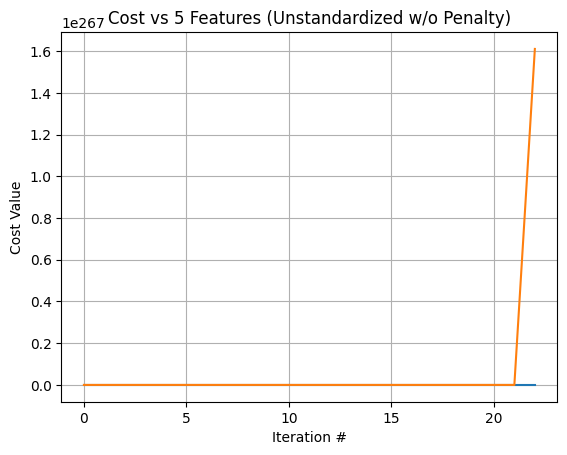

In [7]:
plt.title("Cost vs 5 Features (Unstandardized w/o Penalty)")
plt.xlabel('Iteration #')
plt.ylabel('Cost Value')
plt.grid(True)
plt.plot(cost_tr1)
plt.plot(cost_tst1)

In [8]:
x_trc = data.values[0:train_len,1:12]
x_trc = np.hstack((X0[0:train_len,:], x_trc))
y_trc = data.values[0:train_len, 0]

x_tstc = data.values[train_len:,1:12]
x_tstc = np.hstack((X0[train_len:,:], x_tstc))
y_tstc = data.values[train_len:, 0]

m_c = len(x_trc)
weights = [0]*len(x_trc[0])
alpha = 0.01
iterations = 30
weights, cost_tr2, cost_tst2 = lin_reg(x_trc, y_trc, x_tstc, y_tstc, weights, alpha, iterations)
cost_tr2[-1]
cost_tst2[-1]

/tmp/ipykernel_1022/1582373356.py:16: RuntimeWarning: overflow encountered in square
  cost_tst[i] = (1 / (2 * m)) * np.sum(np.square(errors_tst))
/tmp/ipykernel_1022/1582373356.py:12: RuntimeWarning: overflow encountered in square
  cost_tr[i] = (1 / (2 * m)) * np.sum(np.square(errors_tr))


np.float64(inf)

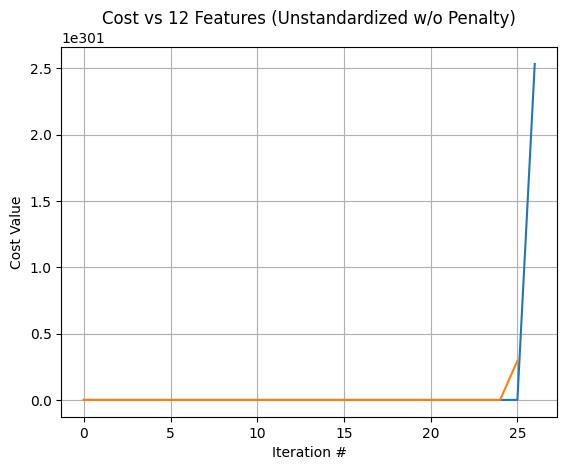

In [9]:
plt.title("Cost vs 12 Features (Unstandardized w/o Penalty)")
plt.xlabel('Iteration #')
plt.ylabel('Cost Value')
plt.grid(True)
plt.plot(cost_tr2)
plt.plot(cost_tst2)

# Problem 2

In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

np.random.seed(0)
train_data, test_data = train_test_split(data, train_size =0.8, test_size=0.2, random_state=100)

normalize_list = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

scaler = MinMaxScaler()

train_data[normalize_list] = scaler.fit_transform(train_data[normalize_list])
test_data[normalize_list] = scaler.fit_transform(test_data[normalize_list])

In [11]:
x_c_train = train_data.values[:,[1, 2, 3, 4, 10]]
x_c_train = np.hstack((X0[0:train_len,:], x_c_train))
y_c_train = train_data.values[:,0]

x_c_test = test_data.values[:,[1, 2, 3, 4, 10]]
x_c_test = np.hstack((X0[train_len:,:], x_c_test))
y_c_test = test_data.values[:,0]

m_nc = len(x_c_train)
weights = [0]*len(x_c_train[0])
alpha = 0.1
iterations = 25
weights, cost_tr3, cost_tst3 = lin_reg(x_c_train, y_c_train, x_c_test, y_c_test, weights, alpha, iterations)

cost_tst3[-1]

np.float64(235651384981.07437)

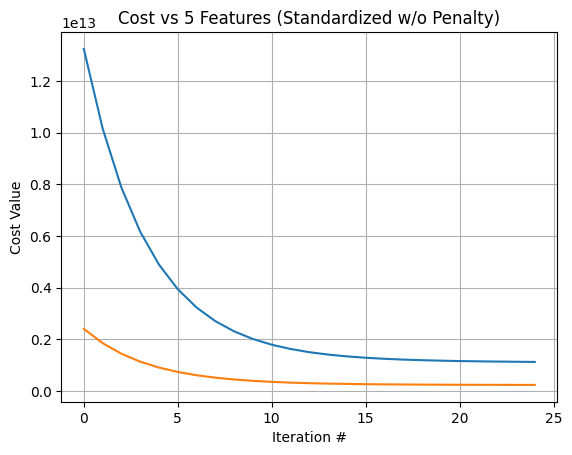

In [12]:
plt.title("Cost vs 5 Features (Standardized w/o Penalty)")
plt.xlabel('Iteration #')
plt.ylabel('Cost Value')
plt.grid(True)
plt.plot(cost_tr3)
plt.plot(cost_tst3)

In [13]:
x_c_train = train_data.values[:,1:12]
x_c_train = np.hstack((X0[0:train_len,:], x_c_train))
y_c_train = train_data.values[:,0]

x_c_test = test_data.values[:,1:12]
x_c_test = np.hstack((X0[train_len:,:], x_c_test))
y_c_test = test_data.values[:,0]

m_nc = len(x_c_train)
weights = [0]*len(x_c_train[0])
alpha = 0.1
iterations = 15
weights, cost_tr4, cost_tst4 = lin_reg(x_c_train, y_c_train, x_c_test, y_c_test, weights, alpha, iterations)
cost_tst4[-1]

np.float64(198680492698.63583)

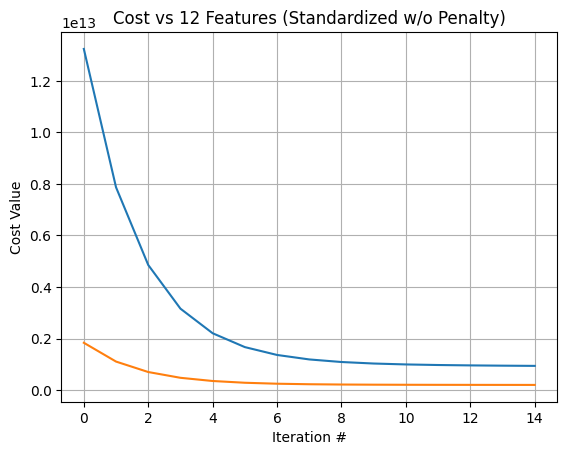

In [14]:
plt.title("Cost vs 12 Features (Standardized w/o Penalty)")
plt.xlabel('Iteration #')
plt.ylabel('Cost Value')
plt.grid(True)
plt.plot(cost_tr4)
plt.plot(cost_tst4)

# Problem 3

In [15]:
def pen_lin_reg(xtr, ytr, xtst, ytst, weights, step, iterations, lam):

  m = len(xtr)
  cost_tr = np.zeros(iterations)
  cost_tst = np.zeros(iterations)
  w = weights

  for i in range(iterations):
    #Train cost
    errors_tr = np.subtract(xtr.dot(w), ytr)
    w = w*(1 - step*lam/m) - (step/m) * xtr.transpose().dot(errors_tr)
    cost_tr[i] = (1 / (2 * m)) * (np.sum(np.square(errors_tr)) + lam*np.sum(np.square(w)))

    #Test cost
    errors_tst = np.subtract(xtst.dot(w), ytst)
    cost_tst[i] = (1 / (2 * m)) * (np.sum(np.square(errors_tst)) + lam*np.sum(np.square(w)))
  return w, cost_tr, cost_tst

In [39]:
x_c_train = train_data.values[:,[1, 2, 3, 4, 10]]
x_c_train = np.hstack((X0[0:train_len,:], x_c_train))
y_c_train = train_data.values[:,0]

x_c_test = test_data.values[:,[1, 2, 3, 4, 10]]
x_c_test = np.hstack((X0[train_len:,:], x_c_test))
y_c_test = test_data.values[:,0]

m_nc = len(x_c_train)
weights = np.zeros(len(x_c_train[0]))
alpha = 0.1
iterations = 25
lam = 0.01
weights, cost_tr5, cost_tst5 = pen_lin_reg(x_c_train, y_c_train, x_c_test, y_c_test, weights, alpha, iterations, lam)

cost_tst5[-1]

np.float64(235847770917.30942)

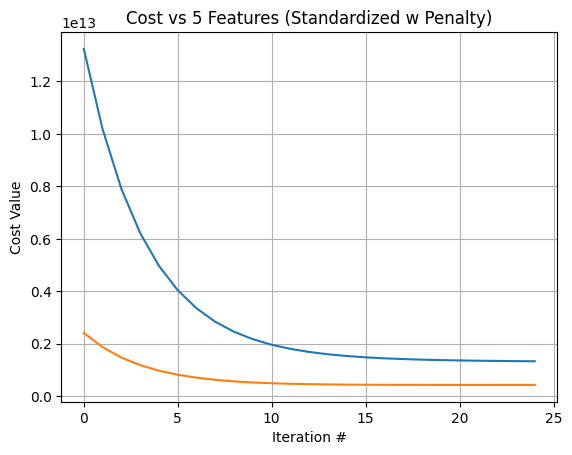

In [17]:
plt.title("Cost vs 5 Features (Standardized w Penalty)")
plt.xlabel('Iteration #')
plt.ylabel('Cost Value')
plt.grid(True)
plt.plot(cost_tr5)
plt.plot(cost_tst5)

In [42]:
x_c_train = train_data.values[:,1:12]
x_c_train = np.hstack((X0[0:train_len,:], x_c_train))
y_c_train = train_data.values[:,0]

x_c_test = test_data.values[:,1:12]
x_c_test = np.hstack((X0[train_len:,:], x_c_test))
y_c_test = test_data.values[:,0]

m_nc = len(x_c_train)
weights = np.zeros(len(x_c_train[0]))
alpha = 0.1
iterations = 15
lam = 30
weights, cost_tr6, cost_tst6 = pen_lin_reg(x_c_train, y_c_train, x_c_test, y_c_test, weights, alpha, iterations, lam)
cost_tst6[-1]

np.float64(514203308082.0949)

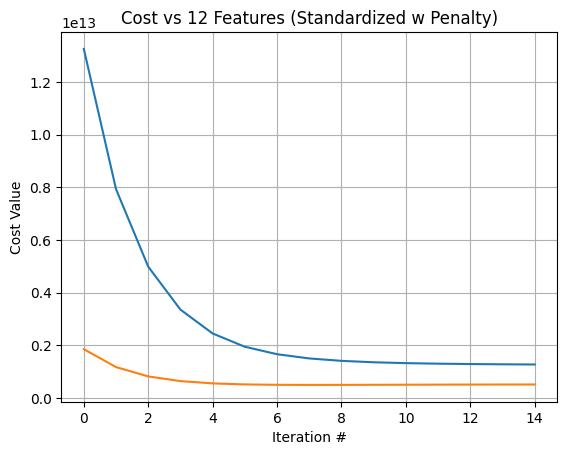

In [43]:
plt.title("Cost vs 12 Features (Standardized w Penalty)")
plt.xlabel('Iteration #')
plt.ylabel('Cost Value')
plt.grid(True)
plt.plot(cost_tr6)
plt.plot(cost_tst6)